/home/sudharshan/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.1
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA GeForce RTX 4070" (12 GiB, sm_89, mempool enabled)
   Kernel cache:
     /home/sudharshan/.cache/warp/1.12.0
Module __main__ 3d9ad5a load on device 'cuda:0' took 335.82 ms  (compiled)


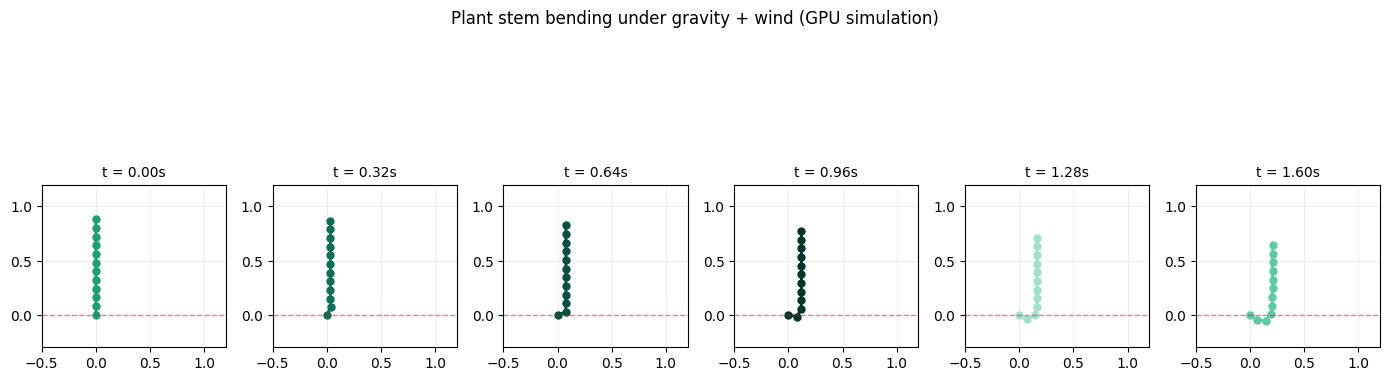

Saved stem_bending.png


In [1]:
import warp as wp
import numpy as np
import matplotlib.pyplot as plt

wp.init()

# GPU only handles the force integration (the parallel part)
@wp.kernel
def apply_forces(
    positions: wp.array(dtype=wp.vec3),
    velocities: wp.array(dtype=wp.vec3),
    dt: float
):
    i = wp.tid()
    if i == 0:
        return
    wind    = wp.vec3(1.5, 0.0, 0.0)
    gravity = wp.vec3(0.0, -1.5, 0.0)
    damping = float(0.85)
    velocities[i] = (velocities[i] + (gravity + wind) * dt) * damping
    positions[i]  =  positions[i]  + velocities[i] * dt

def enforce_constraints_cpu(pos_np, vel_np, rest_length, iters=20):
    """
    Corrects positions on CPU where we can loop root→tip in order.
    This guarantees each node corrects relative to an already-fixed parent.
    """
    for _ in range(iters):
        # Always re-pin root first
        pos_np[0] = [0.0, 0.0, 0.0]
        vel_np[0] = [0.0, 0.0, 0.0]

        # Walk from node 1 to tip — parent is always already corrected
        for i in range(1, len(pos_np)):
            parent = pos_np[i - 1]
            child  = pos_np[i]
            diff   = child - parent
            dist   = np.linalg.norm(diff)
            if dist > 1e-6:
                # Place child exactly rest_length away from parent
                unit       = diff / dist
                pos_np[i]  = parent + unit * rest_length

    return pos_np, vel_np

n           = 12
rest_length = 0.08

pos_np = np.array(
    [[0.0, i * rest_length, 0.0] for i in range(n)],
    dtype=np.float32
)
vel_np = np.zeros((n, 3), dtype=np.float32)

frames = []

for frame in range(120):
    # Upload to GPU → apply forces → download back
    pos_gpu = wp.array(pos_np, dtype=wp.vec3, device="cuda")
    vel_gpu = wp.array(vel_np, dtype=wp.vec3, device="cuda")

    wp.launch(apply_forces, dim=n, inputs=[pos_gpu, vel_gpu, 0.016])

    pos_np = pos_gpu.numpy().copy()
    vel_np = vel_gpu.numpy().copy()

    # Enforce constraints on CPU (ordered root→tip, guaranteed correct)
    pos_np, vel_np = enforce_constraints_cpu(pos_np, vel_np, rest_length, iters=20)

    if frame % 20 == 0:
        frames.append(pos_np.copy())

# --- Plot ---
fig, axes = plt.subplots(1, len(frames), figsize=(14, 5))
colors = ['#1D9E75', '#0F6E56', '#085041', '#04342C', '#9FE1CB', '#5DCAA5']

for idx, (ax, frame_pos) in enumerate(zip(axes, frames)):
    ax.plot(frame_pos[:, 0], frame_pos[:, 1],
            'o-', color=colors[idx % len(colors)],
            linewidth=2, markersize=5)
    ax.set_xlim(-0.5, 1.2)
    ax.set_ylim(-0.3, 1.2)
    ax.set_title(f't = {idx * 20 * 0.016:.2f}s', fontsize=10)
    ax.set_aspect('equal')
    ax.axhline(y=0, color='brown', linewidth=1, linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.2)

plt.suptitle('Plant stem bending under gravity + wind (GPU simulation)', fontsize=12)
plt.tight_layout()
plt.savefig('stem_bending.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved stem_bending.png")

Module __main__ f69a1ec load on device 'cuda:0' took 9.04 ms  (cached)


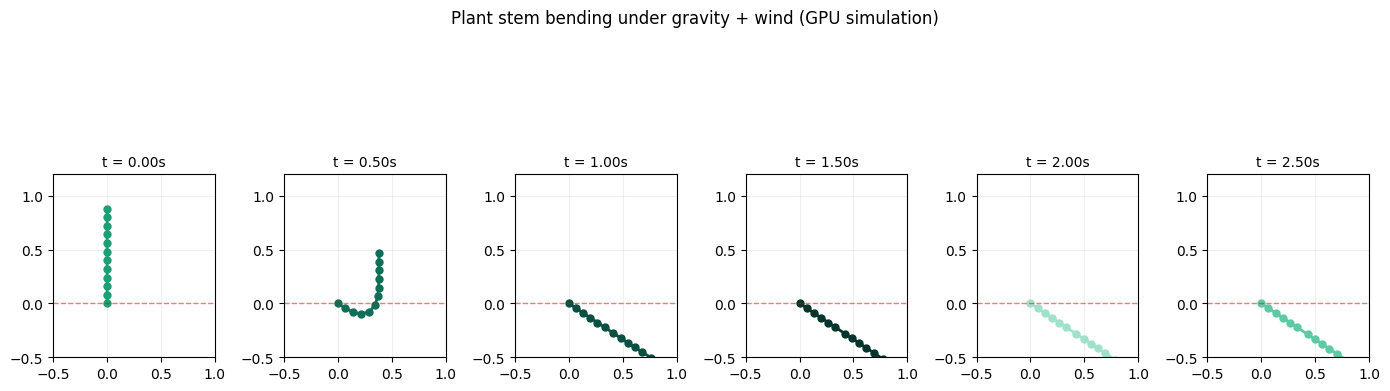

Saved stem_bending.png — this is your Week 1 deliverable proof!


In [2]:
import warp as wp
import numpy as np
import matplotlib.pyplot as plt

wp.init()

@wp.kernel
def apply_forces(
    positions: wp.array(dtype=wp.vec3),
    velocities: wp.array(dtype=wp.vec3),
    dt: float
):
    i = wp.tid()
    if i == 0:
        return  # root fixed

    gravity = wp.vec3(0.0, -2.0, 0.0)   # REDUCED from -9.8 to -2.0
    wind    = wp.vec3(3.0,  0.0, 0.0)   # INCREASED from 2.0 to 3.0
    damping = wp.vec3(
        velocities[i][0] * -0.1,        # damping prevents explosion
        velocities[i][1] * -0.1,
        velocities[i][2] * -0.1
    )
    velocities[i] = velocities[i] + (gravity + wind + damping) * dt
    positions[i]  = positions[i]  + velocities[i] * dt

@wp.kernel
def enforce_distance_constraints(
    positions: wp.array(dtype=wp.vec3),
    rest_length: float
):
    i = wp.tid()
    if i == 0:
        return

    parent = positions[i - 1]
    child  = positions[i]
    diff   = child - parent
    dist   = wp.length(diff)

    if dist > 0.0001:
        correction = diff * (1.0 - rest_length / dist)  # FIXED: removed * 0.5
        positions[i] = parent + diff - correction

@wp.kernel
def pin_root(positions: wp.array(dtype=wp.vec3),
             velocities: wp.array(dtype=wp.vec3)):
    # Explicitly reset root every frame — guarantees it never drifts
    positions[0]  = wp.vec3(0.0, 0.0, 0.0)
    velocities[0] = wp.vec3(0.0, 0.0, 0.0)

n = 12
initial_pos = np.array(
    [[0.0, i * 0.08, 0.0] for i in range(n)],
    dtype=np.float32
)

pos = wp.array(initial_pos, dtype=wp.vec3, device="cuda")
vel = wp.zeros(n, dtype=wp.vec3, device="cuda")

rest_length = 0.08
dt = 0.005          # REDUCED from 0.016 — smaller steps = stable simulation

frames = []
for frame in range(600):            # more frames to fill 2 seconds at dt=0.005
    wp.launch(apply_forces,                   dim=n, inputs=[pos, vel, dt])
    # Run constraint solver 5 times per frame for stability
    for _ in range(5):
        wp.launch(enforce_distance_constraints, dim=n, inputs=[pos, rest_length])
    wp.launch(pin_root, dim=1, inputs=[pos, vel])  # always re-pin root

    if frame % 100 == 0:            # sample every 100 frames
        frames.append(pos.numpy().copy())

# Plot
fig, axes = plt.subplots(1, len(frames), figsize=(14, 5))
colors = ['#1D9E75', '#0F6E56', '#085041', '#04342C', '#9FE1CB', '#5DCAA5']

for idx, (ax, frame_pos) in enumerate(zip(axes, frames)):
    ax.plot(frame_pos[:, 0], frame_pos[:, 1],
            'o-', color=colors[idx % len(colors)],
            linewidth=2, markersize=5)
    ax.set_xlim(-0.5, 1.0)
    ax.set_ylim(-0.5, 1.2)
    ax.set_title(f't = {idx * 100 * dt:.2f}s', fontsize=10)
    ax.set_aspect('equal')
    ax.axhline(y=0, color='red', linewidth=1, linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.2)

plt.suptitle('Plant stem bending under gravity + wind (GPU simulation)', fontsize=12)
plt.tight_layout()
plt.savefig('stem_bending.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved stem_bending.png — this is your Week 1 deliverable proof!")